<a href="https://colab.research.google.com/github/vyaskhyati2019/Home_Loan_Default_Prediction/blob/main/Home_Loan_Default_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🏦 House Loan Data Analysis
### Deep Learning with Keras & TensorFlow — Course-End Project

**Objective:** Build a deep learning model to predict the chance of loan default using historical applicant data.

**Dataset:** 307,511 applicants | 122 features | Binary target (1 = defaulted, 0 = repaid)

---
### Steps:
1. Load dataset
2. Check for null values
3. Print default/payer percentage (TARGET column)
4. Balance the imbalanced dataset
5. Plot balanced vs imbalanced data
6. Encode categorical columns
7. Build deep learning model
8. Calculate Sensitivity (Recall)
9. Calculate AUC-ROC

## 📦 Step 0: Install & Import Libraries

In [1]:
# Install imbalanced-learn for SMOTE (not pre-installed in Colab)
!pip install imbalanced-learn -q

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, recall_score
)
from imblearn.over_sampling import SMOTE

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print('TensorFlow version:', tf.__version__)
print('GPU available:', tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 📂 Step 1: Load the Dataset

Upload `loan_data__1_.csv` when prompted below.

In [3]:
from google.colab import files

print('Please upload loan_data__1_.csv')
uploaded = files.upload()

Please upload loan_data__1_.csv


Saving loan_data__1_.csv to loan_data__1_.csv


In [4]:
filename = list(uploaded.keys())[0]
df = pd.read_csv(filename, encoding='latin1')

print(f'Dataset shape: {df.shape}')
print(f'Rows: {df.shape[0]:,} | Columns: {df.shape[1]}')
df.head(3)

Dataset shape: (307511, 122)
Rows: 307,511 | Columns: 122


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


## 🔍 Step 2: Check for Null Values

In [5]:
null_counts = df.isnull().sum()
null_pct = (df.isnull().sum() / len(df) * 100).round(2)

null_summary = pd.DataFrame({
    'Missing Count': null_counts,
    'Missing %': null_pct
}).query('`Missing Count` > 0').sort_values('Missing %', ascending=False)

print(f'Columns with missing values: {len(null_summary)} out of {df.shape[1]}')
print()
print(null_summary.to_string())

Columns with missing values: 67 out of 122

                              Missing Count  Missing %
COMMONAREA_MEDI                      214865      69.87
COMMONAREA_MODE                      214865      69.87
COMMONAREA_AVG                       214865      69.87
NONLIVINGAPARTMENTS_MODE             213514      69.43
NONLIVINGAPARTMENTS_MEDI             213514      69.43
NONLIVINGAPARTMENTS_AVG              213514      69.43
FONDKAPREMONT_MODE                   210295      68.39
LIVINGAPARTMENTS_AVG                 210199      68.35
LIVINGAPARTMENTS_MEDI                210199      68.35
LIVINGAPARTMENTS_MODE                210199      68.35
FLOORSMIN_MEDI                       208642      67.85
FLOORSMIN_MODE                       208642      67.85
FLOORSMIN_AVG                        208642      67.85
YEARS_BUILD_MODE                     204488      66.50
YEARS_BUILD_MEDI                     204488      66.50
YEARS_BUILD_AVG                      204488      66.50
OWN_CAR_AGE          

/tmp/ipykernel_15736/1089122680.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_missing['Missing %'], y=top_missing.index, palette='Reds_r')


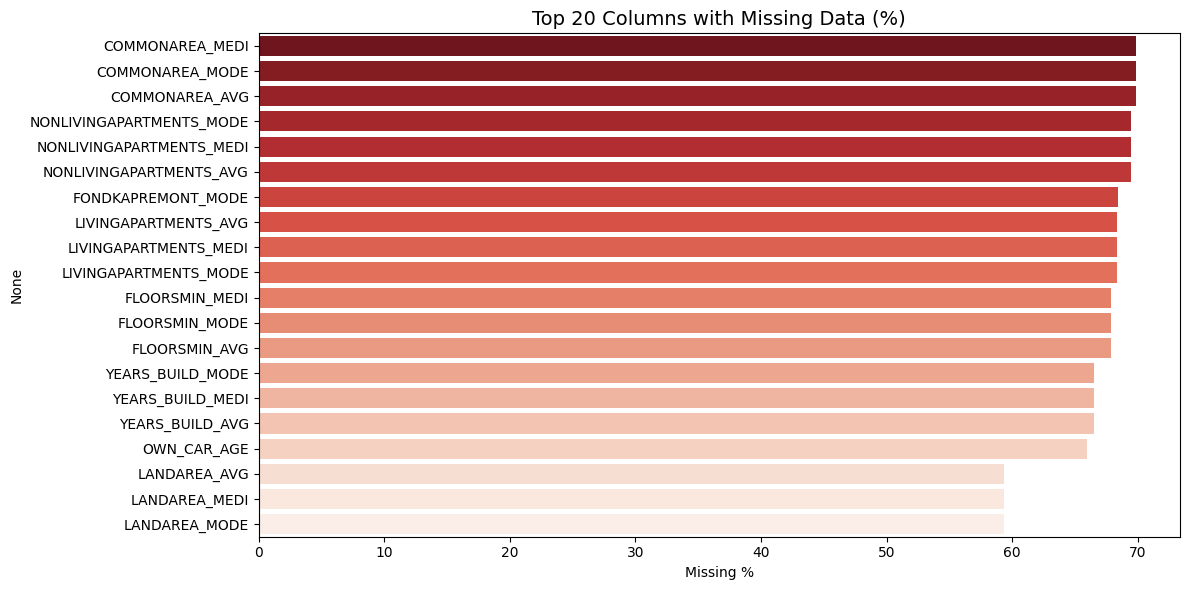

In [6]:
# Visualize top 20 columns with most missing data
top_missing = null_summary.head(20)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_missing['Missing %'], y=top_missing.index, palette='Reds_r')
plt.title('Top 20 Columns with Missing Data (%)', fontsize=14)
plt.xlabel('Missing %')
plt.tight_layout()
plt.show()

## 📊 Step 3: TARGET Column — Default vs Payer Percentage

In [7]:
target_counts = df['TARGET'].value_counts()
target_pct = df['TARGET'].value_counts(normalize=True) * 100

print('=== TARGET Column Distribution ===')
print(f"Repaid (0)   : {target_counts[0]:>7,}  ({target_pct[0]:.2f}%)")
print(f"Defaulted (1): {target_counts[1]:>7,}  ({target_pct[1]:.2f}%)")
print(f"\nImbalance ratio: {target_counts[0]/target_counts[1]:.1f}:1 (repaid:defaulted)")

=== TARGET Column Distribution ===
Repaid (0)   : 282,686  (91.93%)
Defaulted (1):  24,825  (8.07%)

Imbalance ratio: 11.4:1 (repaid:defaulted)


## 📈 Step 5: Plot Imbalanced Data (Before Balancing)

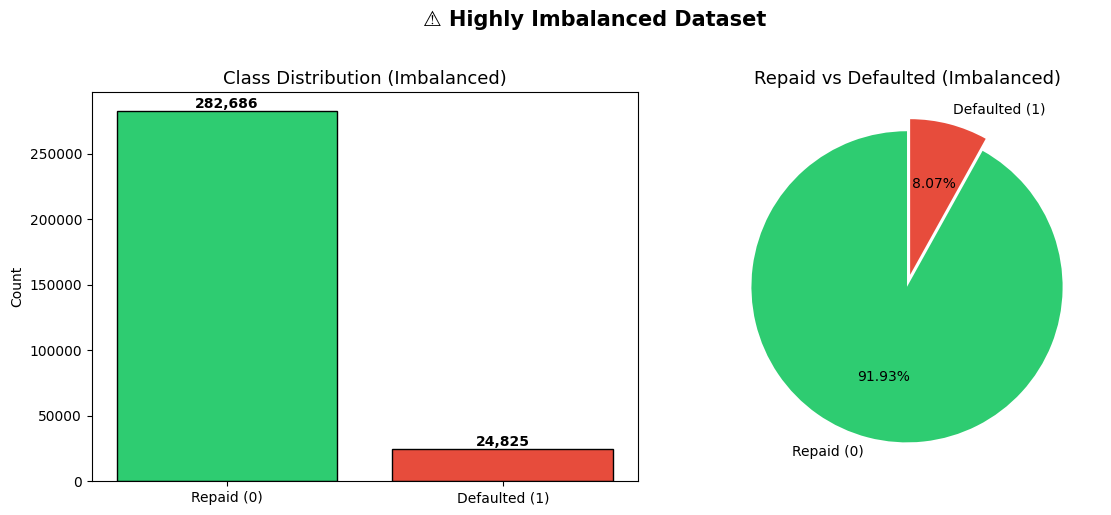

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
labels = ['Repaid (0)', 'Defaulted (1)']
colors = ['#2ecc71', '#e74c3c']
axes[0].bar(labels, [target_counts[0], target_counts[1]], color=colors, edgecolor='black')
axes[0].set_title('Class Distribution (Imbalanced)', fontsize=13)
axes[0].set_ylabel('Count')
for i, v in enumerate([target_counts[0], target_counts[1]]):
    axes[0].text(i, v + 2000, f'{v:,}', ha='center', fontweight='bold')

# Pie chart
axes[1].pie(
    [target_counts[0], target_counts[1]],
    labels=labels,
    autopct='%1.2f%%',
    colors=colors,
    startangle=90,
    explode=(0, 0.08)
)
axes[1].set_title('Repaid vs Defaulted (Imbalanced)', fontsize=13)

plt.suptitle('⚠️ Highly Imbalanced Dataset', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 🔧 Preprocessing: Handle Nulls & Encode Categoricals

Before balancing, we need to prepare the feature matrix.

In [9]:
# Work on a copy
data = df.copy()

# Drop SK_ID_CURR (just an identifier)
data.drop(columns=['SK_ID_CURR'], inplace=True)

# Separate target
y = data['TARGET']
X = data.drop(columns=['TARGET'])

print(f'Features: {X.shape[1]} | Samples: {X.shape[0]:,}')

Features: 120 | Samples: 307,511


## 🔡 Step 6: Encode Categorical Columns

In [10]:
# Identify categorical columns
cat_cols = X.select_dtypes(include=['object']).columns.tolist()
print(f'Categorical columns to encode ({len(cat_cols)}):')
for c in cat_cols:
    print(f'  {c}: {X[c].nunique()} unique values')

Categorical columns to encode (16):
  NAME_CONTRACT_TYPE: 2 unique values
  CODE_GENDER: 3 unique values
  FLAG_OWN_CAR: 2 unique values
  FLAG_OWN_REALTY: 2 unique values
  NAME_TYPE_SUITE: 7 unique values
  NAME_INCOME_TYPE: 8 unique values
  NAME_EDUCATION_TYPE: 5 unique values
  NAME_FAMILY_STATUS: 6 unique values
  NAME_HOUSING_TYPE: 6 unique values
  OCCUPATION_TYPE: 18 unique values
  WEEKDAY_APPR_PROCESS_START: 7 unique values
  ORGANIZATION_TYPE: 58 unique values
  FONDKAPREMONT_MODE: 4 unique values
  HOUSETYPE_MODE: 3 unique values
  WALLSMATERIAL_MODE: 7 unique values
  EMERGENCYSTATE_MODE: 2 unique values


In [11]:
# Label encode each categorical column
# Fill NaN in categoricals with 'Unknown' before encoding
le = LabelEncoder()

for col in cat_cols:
    X[col] = X[col].fillna('Unknown')
    X[col] = le.fit_transform(X[col].astype(str))

print('Categorical encoding complete.')

# Fill remaining numeric nulls with column median
X.fillna(X.median(), inplace=True)

print(f'Remaining null values: {X.isnull().sum().sum()}')

Categorical encoding complete.
Remaining null values: 0


## ⚖️ Step 4: Balance the Dataset using SMOTE

SMOTE (Synthetic Minority Over-sampling Technique) generates synthetic examples for the minority class (defaulters) to create a balanced dataset.

In [12]:
print('Applying SMOTE to balance classes...')
print(f'Before SMOTE: {dict(y.value_counts())}')

smote = SMOTE(random_state=42)
X_balanced, y_balanced = smote.fit_resample(X, y)

balanced_counts = pd.Series(y_balanced).value_counts()
print(f'After SMOTE:  {dict(balanced_counts)}')
print(f'\nTotal samples after balancing: {len(X_balanced):,}')

Applying SMOTE to balance classes...
Before SMOTE: {0: np.int64(282686), 1: np.int64(24825)}
After SMOTE:  {1: np.int64(282686), 0: np.int64(282686)}

Total samples after balancing: 565,372


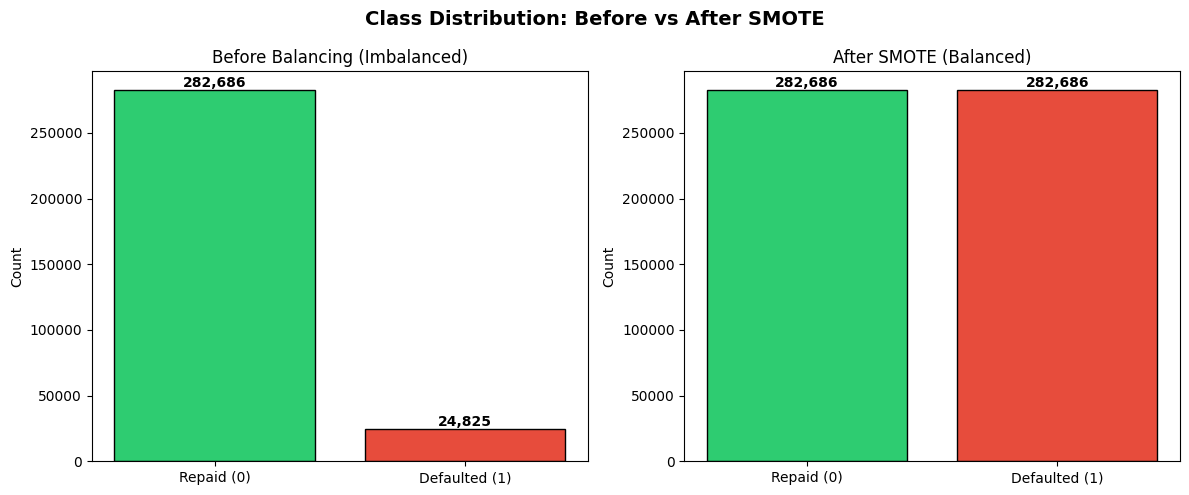

In [13]:
# Plot balanced data
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

labels = ['Repaid (0)', 'Defaulted (1)']
colors = ['#2ecc71', '#e74c3c']

# Before
axes[0].bar(labels, [target_counts[0], target_counts[1]], color=colors, edgecolor='black')
axes[0].set_title('Before Balancing (Imbalanced)', fontsize=12)
axes[0].set_ylabel('Count')
for i, v in enumerate([target_counts[0], target_counts[1]]):
    axes[0].text(i, v + 2000, f'{v:,}', ha='center', fontweight='bold')

# After
axes[1].bar(labels, [balanced_counts[0], balanced_counts[1]], color=colors, edgecolor='black')
axes[1].set_title('After SMOTE (Balanced)', fontsize=12)
axes[1].set_ylabel('Count')
for i, v in enumerate([balanced_counts[0], balanced_counts[1]]):
    axes[1].text(i, v + 2000, f'{v:,}', ha='center', fontweight='bold')

plt.suptitle('Class Distribution: Before vs After SMOTE', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## ✂️ Train-Test Split & Feature Scaling

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X_balanced, y_balanced,
    test_size=0.2,
    random_state=42,
    stratify=y_balanced
)

# Scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f'Training set : {X_train.shape[0]:,} samples')
print(f'Test set     : {X_test.shape[0]:,} samples')
print(f'Features     : {X_train.shape[1]}')

Training set : 452,297 samples
Test set     : 113,075 samples
Features     : 120


## 🧠 Build the Deep Learning Model (Keras)

In [15]:
def build_model(input_dim):
    model = keras.Sequential([
        # Input layer
        layers.Input(shape=(input_dim,)),

        # Hidden layer 1
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.4),

        # Hidden layer 2
        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),

        # Hidden layer 3
        layers.Dense(64, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.2),

        # Hidden layer 4
        layers.Dense(32, activation='relu'),
        layers.Dropout(0.1),

        # Output layer — sigmoid for binary classification
        layers.Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy', keras.metrics.AUC(name='auc'), keras.metrics.Recall(name='recall')]
    )
    return model

model = build_model(X_train.shape[1])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │        30,976 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 76,033 (297.00 KB)

 Trainable params: 75,137 (293.50 KB)

 Non-trainable params: 896 (3.50 KB)

## 🏋️ Train the Model

In [16]:
# Early stopping to prevent overfitting
early_stop = EarlyStopping(
    monitor='val_auc',
    patience=5,
    restore_best_weights=True,
    mode='max',
    verbose=1
)

history = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=512,
    validation_split=0.15,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/30
751/751 ━━━━━━━━━━━━━━━━━━━━ 17s 13ms/step - accuracy: 0.8532 - auc: 0.9237 - loss: 0.3433 - recall: 0.8142 - val_accuracy: 0.8823 - val_auc: 0.9477 - val_loss: 0.2834 - val_recall: 0.8682
Epoch 2/30
751/751 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8805 - auc: 0.9424 - loss: 0.2911 - recall: 0.8356 - val_accuracy: 0.8932 - val_auc: 0.9533 - val_loss: 0.2629 - val_recall: 0.8687
Epoch 3/30
751/751 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8877 - auc: 0.9478 - loss: 0.2751 - recall: 0.8422 - val_accuracy: 0.9008 - val_auc: 0.9575 - val_loss: 0.2472 - val_recall: 0.8738
Epoch 4/30
751/751 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8942 - auc: 0.9518 - loss: 0.2614 - recall: 0.8488 - val_accuracy: 0.9043 - val_auc: 0.9596 - val_loss: 0.2391 - val_recall: 0.8784
Epoch 5/30
751/751 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8987 - auc: 0.9542 - loss: 0.2530 - recall: 0.8536 - val_accuracy: 0.9086 - val_auc: 0.9614 - val_loss: 0.2311 - val_recall: 0.8767
Epoch 6/

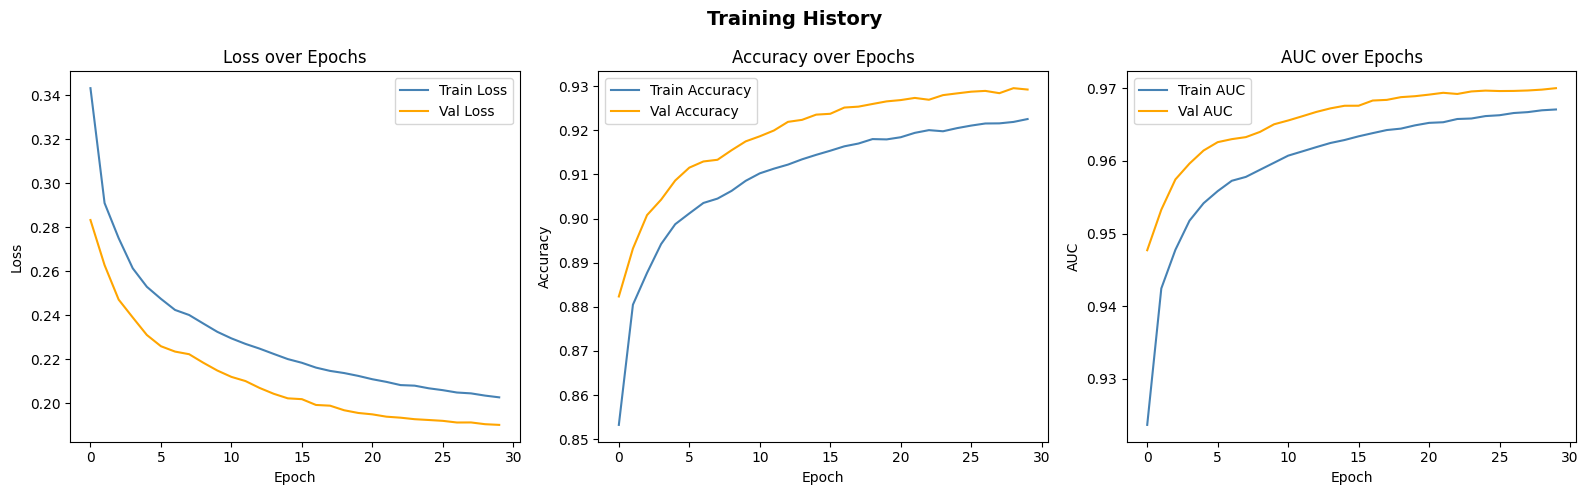

In [17]:
# Plot training history
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Loss
axes[0].plot(history.history['loss'], label='Train Loss', color='steelblue')
axes[0].plot(history.history['val_loss'], label='Val Loss', color='orange')
axes[0].set_title('Loss over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

# Accuracy
axes[1].plot(history.history['accuracy'], label='Train Accuracy', color='steelblue')
axes[1].plot(history.history['val_accuracy'], label='Val Accuracy', color='orange')
axes[1].set_title('Accuracy over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

# AUC
axes[2].plot(history.history['auc'], label='Train AUC', color='steelblue')
axes[2].plot(history.history['val_auc'], label='Val AUC', color='orange')
axes[2].set_title('AUC over Epochs')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('AUC')
axes[2].legend()

plt.suptitle('Training History', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 📋 Evaluate the Model

In [18]:
# Predictions
y_pred_proba = model.predict(X_test).flatten()
y_pred = (y_pred_proba >= 0.5).astype(int)

print('=== Test Set Evaluation ===')
loss, accuracy, auc, recall = model.evaluate(X_test, y_test, verbose=0)
print(f'Loss     : {loss:.4f}')
print(f'Accuracy : {accuracy:.4f}')
print(f'AUC      : {auc:.4f}')
print(f'Recall   : {recall:.4f}')

3534/3534 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step
=== Test Set Evaluation ===
Loss     : 0.1899
Accuracy : 0.9285
AUC      : 0.9706
Recall   : 0.8865


## 🎯 Step 7: Sensitivity (Recall) for Default Class

In [19]:
sensitivity = recall_score(y_test, y_pred)

print('=== Sensitivity (Recall) ===')
print(f'Sensitivity for Defaulters (class 1): {sensitivity:.4f} ({sensitivity*100:.2f}%)')
print()
print('Interpretation:')
print(f'  The model correctly identifies {sensitivity*100:.1f}% of actual loan defaulters.')
print(f'  In a lending context, HIGH sensitivity = fewer missed defaulters = lower financial risk.')
print()
print('=== Full Classification Report ===')
print(classification_report(y_test, y_pred, target_names=['Repaid (0)', 'Defaulted (1)']))

=== Sensitivity (Recall) ===
Sensitivity for Defaulters (class 1): 0.8865 (88.65%)

Interpretation:
  The model correctly identifies 88.6% of actual loan defaulters.
  In a lending context, HIGH sensitivity = fewer missed defaulters = lower financial risk.

=== Full Classification Report ===
               precision    recall  f1-score   support

   Repaid (0)       0.90      0.97      0.93     56538
Defaulted (1)       0.97      0.89      0.93     56537

     accuracy                           0.93    113075
    macro avg       0.93      0.93      0.93    113075
 weighted avg       0.93      0.93      0.93    113075



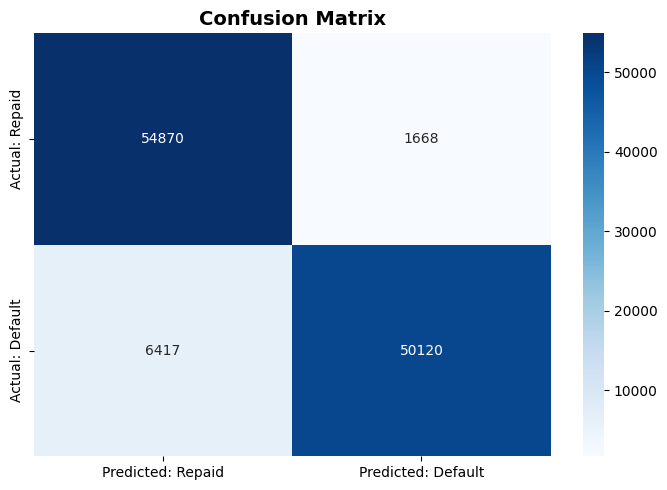

True Negatives  (Correctly predicted Repaid)   : 54,870
False Positives (Predicted Default, Actually Repaid): 1,668
False Negatives (Missed Defaulters)            : 6,417
True Positives  (Correctly predicted Default)  : 50,120


In [20]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Predicted: Repaid', 'Predicted: Default'],
    yticklabels=['Actual: Repaid', 'Actual: Default']
)
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'True Negatives  (Correctly predicted Repaid)   : {tn:,}')
print(f'False Positives (Predicted Default, Actually Repaid): {fp:,}')
print(f'False Negatives (Missed Defaulters)            : {fn:,}')
print(f'True Positives  (Correctly predicted Default)  : {tp:,}')

## 📉 Step 8: AUC-ROC Curve

AUC-ROC Score: 0.9707


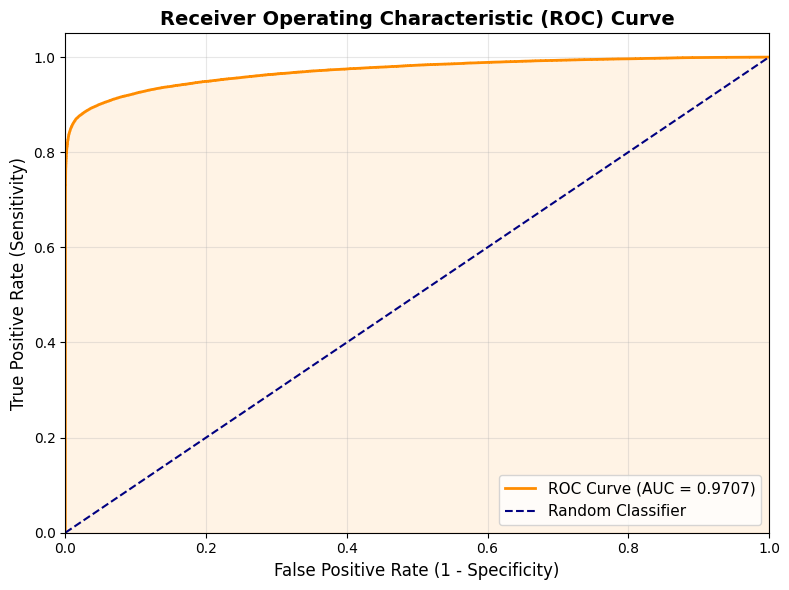


Interpretation:
  AUC = 0.9707 — The model has a 97.1% chance of ranking
  a randomly chosen defaulter higher than a randomly chosen repayer.
  AUC > 0.90 = Excellent | 0.80-0.90 = Good | 0.70-0.80 = Fair | < 0.70 = Poor


In [21]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
auc_score = roc_auc_score(y_test, y_pred_proba)

print(f'AUC-ROC Score: {auc_score:.4f}')

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--', label='Random Classifier')
plt.fill_between(fpr, tpr, alpha=0.1, color='darkorange')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Sensitivity)', fontsize=12)
plt.title('Receiver Operating Characteristic (ROC) Curve', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print()
print('Interpretation:')
print(f'  AUC = {auc_score:.4f} — The model has a {auc_score*100:.1f}% chance of ranking')
print('  a randomly chosen defaulter higher than a randomly chosen repayer.')
print('  AUC > 0.90 = Excellent | 0.80-0.90 = Good | 0.70-0.80 = Fair | < 0.70 = Poor')

## 📊 Final Summary

In [22]:
print('=' * 50)
print('       FINAL MODEL PERFORMANCE SUMMARY')
print('=' * 50)
print(f'  Dataset size       : {len(df):,} applicants')
print(f'  Features used      : {X_train.shape[1]}')
print(f'  Balancing method   : SMOTE')
print(f'  Model architecture : 4-layer Deep Neural Network')
print(f'  Test Accuracy      : {accuracy*100:.2f}%')
print(f'  Sensitivity/Recall : {sensitivity*100:.2f}%')
print(f'  AUC-ROC Score      : {auc_score:.4f}')
print('=' * 50)

       FINAL MODEL PERFORMANCE SUMMARY
  Dataset size       : 307,511 applicants
  Features used      : 120
  Balancing method   : SMOTE
  Model architecture : 4-layer Deep Neural Network
  Test Accuracy      : 92.85%
  Sensitivity/Recall : 88.65%
  AUC-ROC Score      : 0.9707
